In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from math import ceil
import socket
import scipy.signal as signal
import glob
import time
from random import randint
%matplotlib widget

## Notebook Setup

##### Append Code and Data Repository Paths

In [2]:
# Path to get to /home/rfsoc
home_dir = Path("./../../..")
os.chdir(home_dir)

# Paths relative to /home/rfsoc
primecam_readout = Path('./primecam_readout')
ccatkidlib = Path('./ccatkidlib')
data_dir = Path('./../../mnt/md0')
 
# Append paths
sys.path.insert(0, os.path.abspath(ccatkidlib / 'rfsoc')) # Path contaning rfsoc_daq

##### Load Local Modules

In [3]:
%load_ext autoreload
%autoreload 2

from rfsoc_daq import R
import rfsoc_io
from rfsoc_timestream import Streamer

---

## Data Acquisiton

In [5]:
# Initialize Control Object
R = R()

INFO | Successfully initialized logger: rfsoc_io
Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=False, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=False, running=True
INFO | Initialized RFSoC agent. Communicating with drones: ['1.1', '1.3']!
INFO | Successfully initialized timestream object using address 192.168.3.40 and port 4096!
INFO | Set NCLO to [850, 500] MHz for drones: ['1.1', '1.3']!
Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=False, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=False, running=True
INFO | Successfully set drive attenuation to [10, 10] for drones ['1.1', '1.3']!
INFO | Successfully set sense attenuation to [2, 2] for drones ['1.1', '1.3']!


In [32]:
R.find_detectors(new_sweep = False, peak_prom_std = 10, peak_prom_dB = 0, width_min = 5, width_max = 100, peak_dis = 100)

Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D1' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D2' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D3' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D4' with identifier 'T*'
Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
INFO | Writing new VNA comb!
INFO | 

Writing custom target comb: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 117/117 [01:57<00:00,  1.00s/it]


INFO | Found 109 detectors for drone 1.1!
INFO | Found 35 detectors for drone 1.2!
INFO | Found 1 detectors for drone 1.3!
INFO | Found 528 detectors for drone 1.4!


[109, 35, 1, 528]

In [5]:
R.take_target_sweep(com_to = ['1.2'], tone_freqs = [[500e6]], tone_powers = [[54]], tone_phis = [[0]])

Status: Drone 1.1: ip=192.168.2.99, to_run=False, running=True
Stopping drone 1.1 (for 43200 s)... Done.
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=False, running=True
Stopping drone 1.3 (for 43200 s)... Done.
Status: Drone 1.4: ip=192.168.2.99, to_run=False, running=True
Stopping drone 1.4 (for 43200 s)... Done.
INFO | Sucessfully wrote custom comb for board 1!
INFO | Taking target sweep!
INFO | Finished taking target sweep for board 1!


[PosixPath('/mnt/md0/TEMP_DATA/targ/20241202/1733167446/B1D2/TEST_targ_1733167643.npy')]

In [6]:
R.take_timestream(10)

Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=False, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=False, running=False
Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=False, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=False, running=False
INFO | Sucessfully wrote custom comb for drone 1.1!
INFO | Sucessfully wrote custom comb for drone 1.3!
INFO | Taking 10 seconds of timestream data!
INFO | Finished taking timestream data for drone 1.1!
INFO | Finished taking timestream data for drone 1.3!


[[PosixPath('/mnt/md0/TEMP_DATA/timestream/20241202/1733170133/B1D1/TEST_tstream_1733170214_001.npy')],
 [PosixPath('/mnt/md0/TEMP_DATA/timestream/20241202/1733170133/B1D3/TEST_tstream_1733170214_001.npy')]]

---

## Data Processing

In [271]:
# Data Directory Name
data_name = 'modcam_coldload_data'
date = '20241213'
sess_id = '1733352435'

In [272]:
# Load init IO config
io_cfg_name = f'{sess_id}_init_config_io.yaml'
cfg_dir = data_dir / data_name / 'rfsoc' / date / sess_id

io_cfg = rfsoc_io.load_config(cfg_dir / io_cfg_name)
print(io_cfg)

{'sess_id': '1733352435', 'drone_list': ['1.1', '1.2', '1.3', '1.4'], 'initialize': True, 'parallel': False, 'restart': False, 'udp_ip': '192.168.3.40', 'udp_port': 4096, 'boards': {'b1': {'board_ip': '192.168.2.99', 'sampling_freq': 488.28, 'drone_cfg': '/home/rfsoc/ccatkidlib/scripts/modcam_coldload/coldload_drone_config.yaml'}, 'b2': {'board_ip': '192.168.2.98', 'sampling_freq': 488.28, 'drone_cfg': '/home/rfsoc/ccatkidlib/rfsoc/drones_config_2.yaml'}}, 'file_paths': {'analysis_dir': '/home/rfsoc/ccatkidlib/analysis/', 'data_dir': '/mnt/md0/modcam_coldload_data', 'tmp_data_dir': '/home/rfsoc/primecam_readout/src/tmp', 'primecam_readout': '/home/rfsoc/primecam_readout/src/', 'master_drone_list': '/home/rfsoc/primecam_readout/master_drone_list.yaml', 'pcs_dir': '/home/rfsoc/ocs-site-configs/', 'RSA_key': '/home/rfsoc/.ssh/xilinx', 'drone_dir': '/home/xilinx/primecam_readout/drones'}, 'file_names': {'stream_fname': 'coldload_tstream', 'targ_fname': 'coldload_targ', 'vna_fname': 'coldlo

In [209]:
# Get parameters from io_cfg
drone_list = io_cfg['drone_list']
print(drone_list)

['1.1', '1.2', '1.3', '1.4']


### Sweeps

In [259]:
def plot_sweep(sweep_file, figax = None, label = "", n = 10, fix_offset=True):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax
    
    # Load VNA sweep data
    fs, s21z = np.load(sweep_file)
    fs = np.abs(fs) 
    s21m = np.abs(s21z)
    s21dB = 20*np.log10(s21m)#
    if fix_offset:
        offset = np.median(signal.medfilt(s21dB, kernel_size = n)[n:])
    else:
        offset = 0
        
    #ax.plot(fs[n:]/1e6, signal.medfilt(s21dB, kernel_size = n)[n:] - offset, label = label)
    ax.plot(fs/1e6, s21dB- offset, label = label)
    #ax.set_xlabel("Frequency (MHz)")
    #ax.set_ylabel("|S21| (dB)")

    # Create legend if label was provided
    if label != "":
        ax.legend(loc = 1)
        
    return fs, s21z

##### VNA Sweeps

In [273]:
# Define VNA sweep data directory
vna_sweep_name = 'coldload_vna_'
vna_dir = data_dir / data_name / 'vna' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(vna_dir / dir_name)))

B1D1/: ['coldload_vna_1733353943.npy', 'coldload_vna_1733352572.npy', 'coldload_vna_1733374002.npy', 'coldload_vna_1733361177.npy', 'coldload_vna_1733359769.npy', 'coldload_vna_1733360367.npy', 'coldload_vna_1733354787.npy', 'coldload_vna_1733366776.npy', 'coldload_vna_1733353368.npy', 'coldload_vna_1733372600.npy', 'coldload_vna_1733371784.npy', 'coldload_vna_1733366187.npy', 'coldload_vna_1733373179.npy', 'coldload_vna_1733358953.npy', 'coldload_vna_1733367614.npy', 'coldload_vna_1733365357.npy']
B1D2/: ['coldload_vna_1733353943.npy', 'coldload_vna_1733352572.npy', 'coldload_vna_1733374002.npy', 'coldload_vna_1733361177.npy', 'coldload_vna_1733359769.npy', 'coldload_vna_1733360367.npy', 'coldload_vna_1733354787.npy', 'coldload_vna_1733366776.npy', 'coldload_vna_1733353368.npy', 'coldload_vna_1733372600.npy', 'coldload_vna_1733371784.npy', 'coldload_vna_1733366187.npy', 'coldload_vna_1733373179.npy', 'coldload_vna_1733358953.npy', 'coldload_vna_1733367614.npy', 'coldload_vna_173336535

In [212]:
#Find parameters
bid, drid = (1, 4)
dir_name = f'B{bid}D{drid}/'
vna_conf_list = glob.glob(str(cfg_dir / dir_name / "*_vna_config_drone.yaml"))
#os.listdir(cfg_dir / dir_name )#/ "*_vna_config_drone.yaml")
all_ctimes = []
for conf in np.sort(vna_conf_list):
    ctime = conf.split(dir_name)[1].split('_vna')[0]
    vna_config = rfsoc_io.load_config(conf)
    atts = vna_config['atten']
    all_ctimes.append(ctime)
    print(ctime + ":", atts, time.ctime(int(ctime)))

1733427473: {'drive': 0, 'sense': 0} Thu Dec  5 14:37:53 2024
1733428252: {'drive': 3, 'sense': 0} Thu Dec  5 14:50:52 2024
1733428764: {'drive': 6, 'sense': 0} Thu Dec  5 14:59:24 2024
1733429518: {'drive': 12, 'sense': 0} Thu Dec  5 15:11:58 2024


Text(0.5, 0.98, 'VNA Traces')

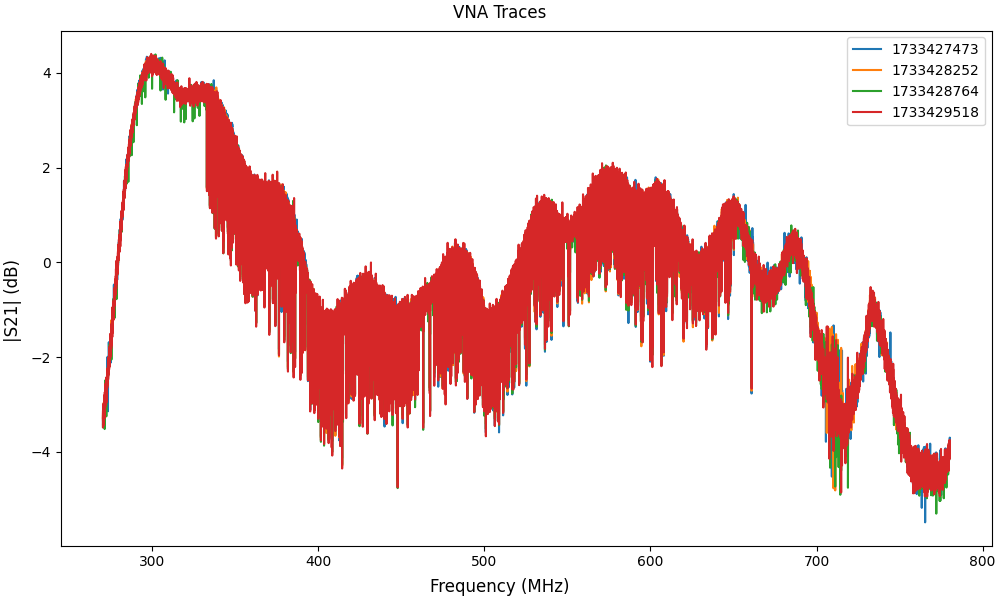

In [267]:
# Define timestamp of VNA sweeps
timestamps = all_ctimes#['1733352572', '1733353368', '1733353943', '1733354787', '1733365357','1733366776', '1733367614']

# Plot VNA sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = 1#ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all VNA sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_vna, axes = plt.subplots(num_rows, num_cols, figsize = (10, 6), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
for timestamp in timestamps:
    bid, drid = (1, 4)
    fname = vna_dir / (f'B{bid}D{drid}/' + vna_sweep_name + timestamp + ".npy")
    plot_sweep(fname, figax = (fig_vna, axes), label = timestamp, n = 3)
fig_vna.supxlabel("Frequency (MHz)")
fig_vna.supylabel("|S21| (dB)")
fig_vna.suptitle("VNA Traces")

Text(0.5, 0.98, 'VNA Traces')

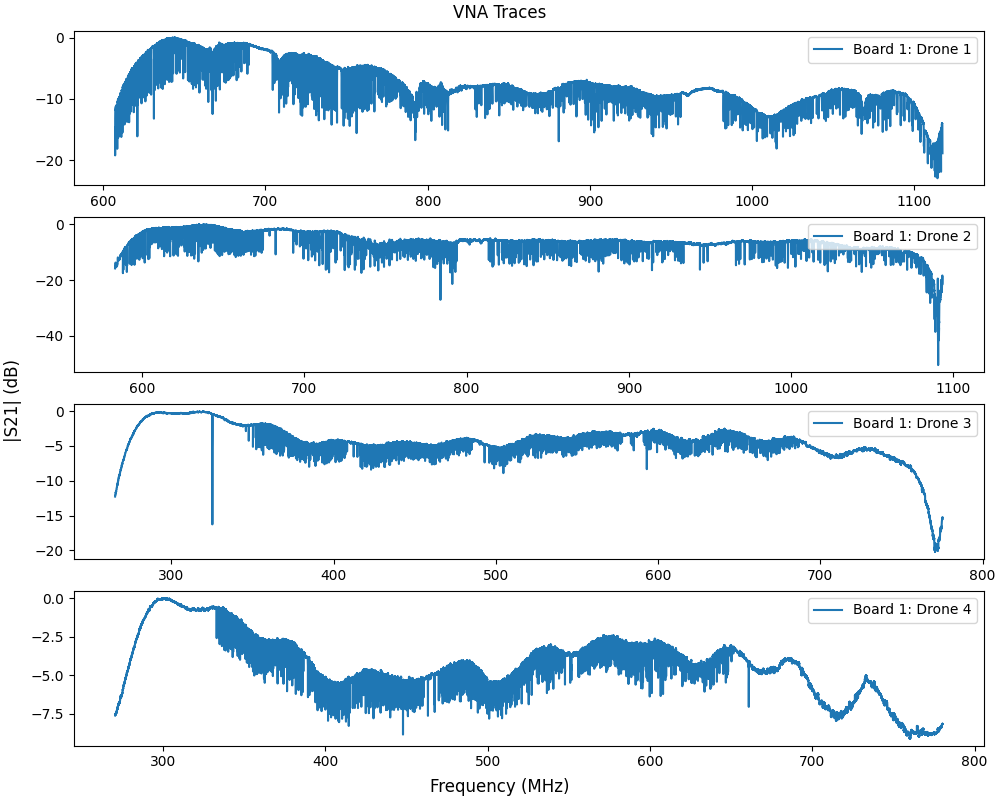

In [214]:
# Define timestamp of VNA sweeps
timestamp = '1733427473'

# Plot VNA sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all VNA sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_vna, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
for drone, ax in zip(drone_list, np.ndarray.flatten(axes)):
    bid, drid = drone.split('.')
    fname = vna_dir / (f'B{bid}D{drid}/' + vna_sweep_name + timestamp + ".npy")
    plot_sweep(fname, figax = (fig_vna, ax), label = f'Board {bid}: Drone {drid}', n = 7)
fig_vna.supxlabel("Frequency (MHz)")
fig_vna.supylabel("|S21| (dB)")
fig_vna.suptitle("VNA Traces")

---

#### Target Sweep

In [215]:
# Define target sweep data directory
targ_sweep_name = 'coldload_targ_'
targ_dir = data_dir / data_name / 'targ' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(targ_dir / dir_name)))

B1D1/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']
B1D2/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']
B1D3/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']
B1D4/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']


In [216]:
#Find parameters
bid, drid = (1, 2)
dir_name = f'B{bid}D{drid}/'
vna_conf_list = glob.glob(str(cfg_dir / dir_name / "*_targ_config_drone.yaml"))
#os.listdir(cfg_dir / dir_name )#/ "*_vna_config_drone.yaml")
for conf in np.sort(vna_conf_list):
    ctime = conf.split(dir_name)[1].split('_targ')[0]
    vna_config = rfsoc_io.load_config(conf)
    atts = vna_config['atten']
    print(ctime + ":", atts, time.ctime(int(ctime)))

1733427865: {'drive': 0, 'sense': 0} Thu Dec  5 14:44:25 2024
1733428631: {'drive': 3, 'sense': 0} Thu Dec  5 14:57:11 2024
1733429139: {'drive': 6, 'sense': 0} Thu Dec  5 15:05:39 2024
1733429906: {'drive': 12, 'sense': 0} Thu Dec  5 15:18:26 2024


Text(0.5, 0.98, 'VNA Traces')

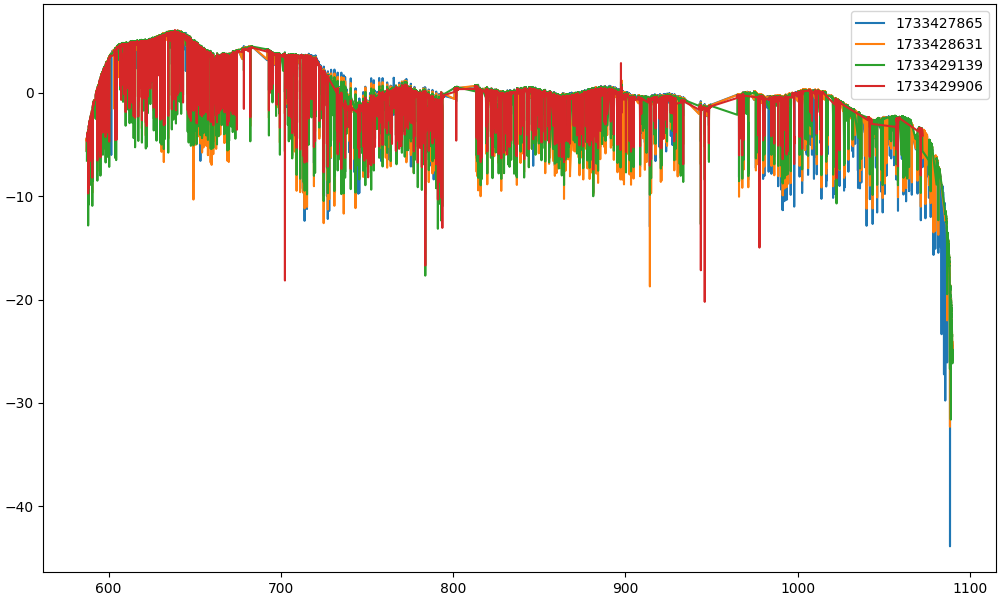

In [268]:
# Define timestamp of VNA sweeps
timestamps = ['1733427865', '1733428631','1733429139', '1733429906']#['1733353810', '1733360225','1733366624', '1733373037']

# Plot VNA sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = 1#ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all VNA sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_targ, axes = plt.subplots(num_rows, num_cols, figsize = (10, 6), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
for timestamp in timestamps:
    bid, drid = (1, 2)
    fname = targ_dir / (f'B{bid}D{drid}/' + targ_sweep_name + timestamp + ".npy")
    plot_sweep(fname, figax = (fig_targ, axes), label = timestamp, n = 7, fix_offset=True)
fig_vna.supxlabel("Frequency (MHz)")
fig_vna.supylabel("|S21| (dB)")
fig_vna.suptitle("VNA Traces")

Text(0.5, 0.98, 'Target Traces')

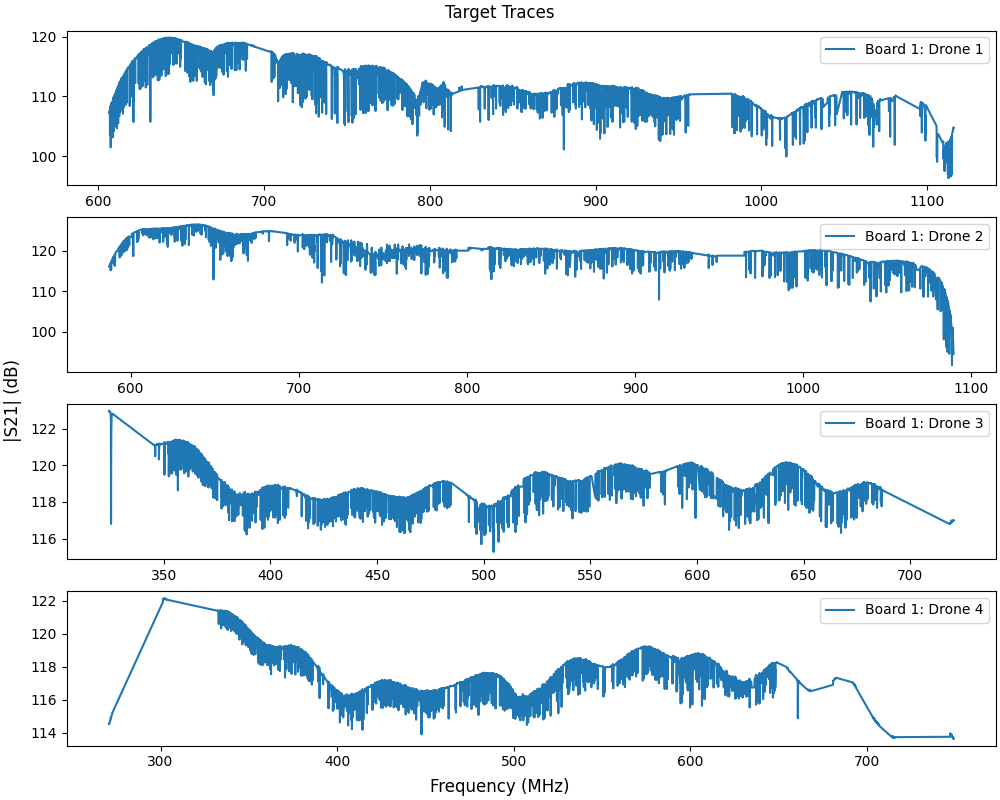

In [162]:
# Define timestamp of target sweeps
timestamp = '1733352435'

# Plot target sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all target sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_targ)
except:
    print("No figures currently open")

fig_targ, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
for drone, ax in zip(drone_list, np.ndarray.flatten(axes)):
    bid, drid = drone.split('.')
    fname = targ_dir / (f'B{bid}D{drid}/' + targ_sweep_name + timestamp + ".npy")
    plot_sweep(fname, figax = (fig_targ, ax), label = f'Board {bid}: Drone {drid}', n = 7)
fig_targ.supxlabel("Frequency (MHz)")
fig_targ.supylabel("|S21| (dB)")
fig_targ.suptitle("Target Traces")

---

### Timestreams

In [63]:
def plot_tstream(tstream_file, chans = None, figax = None, label = ""):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax

    try:
        chan_num = len(chans)
    except:
        chans = [chans]
        chan_num = len(chans)
    
    # Load timestream data
    data = np.load(tstream_file)
    ts = data[0]

    for chan in chans:
        s21z = data[chan]
        s21m = np.abs(s21z)
        ax.plot(ts, 20*np.log10(s21m), label = label + f', Channel: {chan}')
        #ax.set_xlabel("Frequency (MHz)")
        #ax.set_ylabel("|S21| (dB)")

        # Create legend if label was provided
        if label != "":
            ax.legend(loc = 1)

[187, 186, 79, 9, 86] 205


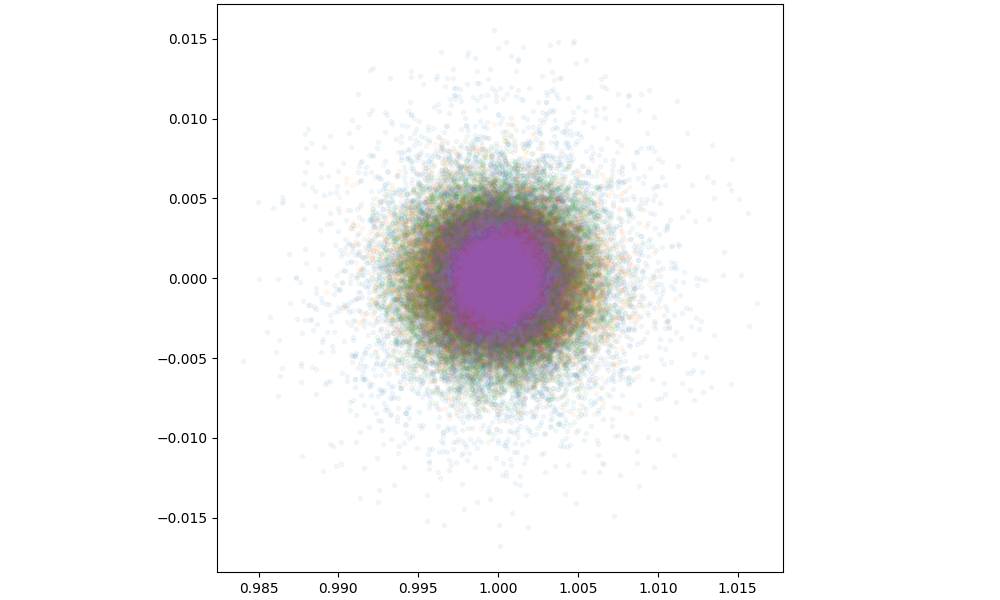

In [274]:
bid = 1
drid = 2
plt.clf()
plt.gca().set_aspect('equal')
N = [randint(0, n_dets-1) for i in range(5)]
colors = ['r', 'b', 'g', 'y', 'm']

for j, n in enumerate(N):
    noise_data = np.array([])
    for i in range(2):
        fname = tstream_dir / (f'B{bid}D{drid}/' + f'coldload_tstream_1733427943_00{i+1}.npy')
        data = np.load(fname)
        noise_data = np.append(noise_data, data[n])
        n_dets, counts = data.shape
    

    #plt.plot(i, np.abs(data[n].mean()), "*", c=colors[j])
    data = noise_data/noise_data.mean()
    plt.plot(data.real, data.imag, ".", alpha = 0.05)
    
print(N, n_dets)
#plt.xlim(-300000, 200000)
#plt.ylim(-200000, 300000)
plt.show()

In [226]:
# Define timestream data directory
tstream_name = 'coldload_tstream_'
tstream_dir = data_dir / data_name / 'timestream' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(tstream_dir / dir_name)))

B1D1/: ['coldload_tstream_1733429218_001.npy', 'coldload_tstream_1733427943_002.npy', 'coldload_tstream_1733427943_001.npy', 'coldload_tstream_1733429218_002.npy']
B1D2/: ['coldload_tstream_1733429218_001.npy', 'coldload_tstream_1733427943_002.npy', 'coldload_tstream_1733427943_001.npy', 'coldload_tstream_1733429218_002.npy']
B1D3/: ['coldload_tstream_1733429218_001.npy', 'coldload_tstream_1733427943_002.npy', 'coldload_tstream_1733427943_001.npy', 'coldload_tstream_1733429218_002.npy']
B1D4/: ['coldload_tstream_1733429218_001.npy', 'coldload_tstream_1733427943_002.npy', 'coldload_tstream_1733427943_001.npy', 'coldload_tstream_1733429218_002.npy']


In [111]:
#Find parameters
bid, drid = (1, 2)
dir_name = f'B{bid}D{drid}/'
vna_conf_list = glob.glob(str(cfg_dir / dir_name / "*_timestream_config_drone.yaml"))
#os.listdir(cfg_dir / dir_name )#/ "*_vna_config_drone.yaml")
for conf in np.sort(vna_conf_list):
    ctime = conf.split(dir_name)[1].split('_timestream')[0]
    vna_config = rfsoc_io.load_config(conf)
    atts = vna_config['atten']
    print(ctime + ":", atts, time.ctime(int(ctime)))

1733292883: {'drive': 0, 'sense': 0} Wed Dec  4 01:14:43 2024
1733294356: {'drive': 6, 'sense': 0} Wed Dec  4 01:39:16 2024
1733298206: {'drive': 0, 'sense': 0} Wed Dec  4 02:43:26 2024
1733299662: {'drive': 6, 'sense': 0} Wed Dec  4 03:07:42 2024
1733303495: {'drive': 0, 'sense': 0} Wed Dec  4 04:11:35 2024
1733305002: {'drive': 6, 'sense': 0} Wed Dec  4 04:36:42 2024


In [114]:
print(vna_config.keys())
print(vna_config['tones'].keys())
print(vna_config['det_find'])
#print(vna_config['tones'])

dict_keys(['sess_id', 'com_to', 'udp_source_ip', 'udp_source_port', 'tones', 'atten', 'det_config', 'det_find'])
dict_keys(['NCLO', 'bandwidth', 'N_step', 'dB', 'num_tones', 'tone_freqs', 'tone_powers', 'tone_phis'])
{'peak_prom_std': 5, 'peak_prom_db': 0, 'peak_dis': 100, 'width_min': 5, 'width_max': 100, 'stitch': True, 'stitch_sw': 100, 'continuum_wn': 300, 'remove_cont': True, 'remove_noise': True, 'noise_wn': 30000}


In [103]:
#Find parameters
bid, drid = (1, 1)
dir_name = f'B{bid}D{drid}/'
vna_conf_list = glob.glob(str(cfg_dir / dir_name / "*_config_drone.yaml"))
#os.listdir(cfg_dir / dir_name )#/ "*_vna_config_drone.yaml")
for conf in np.sort(vna_conf_list):
    ctime = conf.split(dir_name)[1].split('_')[0]
    conf_name = conf.split(dir_name)[1].split('_')[1]
    vna_config = rfsoc_io.load_config(conf)
    atts = vna_config['atten']
    print(conf_name, ctime + ":", atts, time.ctime(int(ctime)))

init 1733290445: {'drive': 2, 'sense': 0} Wed Dec  4 00:34:05 2024
vna 1733292316: {'drive': 0, 'sense': 0} Wed Dec  4 01:05:16 2024
targ 1733292757: {'drive': 0, 'sense': 0} Wed Dec  4 01:12:37 2024
timestream 1733292883: {'drive': 0, 'sense': 0} Wed Dec  4 01:14:43 2024
vna 1733293197: {'drive': 3, 'sense': 0} Wed Dec  4 01:19:57 2024
targ 1733293641: {'drive': 3, 'sense': 0} Wed Dec  4 01:27:21 2024
vna 1733293768: {'drive': 6, 'sense': 0} Wed Dec  4 01:29:28 2024
targ 1733294231: {'drive': 6, 'sense': 0} Wed Dec  4 01:37:11 2024
timestream 1733294356: {'drive': 6, 'sense': 0} Wed Dec  4 01:39:16 2024
vna 1733294667: {'drive': 12, 'sense': 0} Wed Dec  4 01:44:27 2024
targ 1733295123: {'drive': 12, 'sense': 0} Wed Dec  4 01:52:03 2024
vna 1733295247: {'drive': 18, 'sense': 0} Wed Dec  4 01:54:07 2024
targ 1733295694: {'drive': 18, 'sense': 0} Wed Dec  4 02:01:34 2024
vna 1733297633: {'drive': 0, 'sense': 0} Wed Dec  4 02:33:53 2024
targ 1733298080: {'drive': 0, 'sense': 0} Wed Dec  4

Text(0.5, 0.98, 'Timestreams')

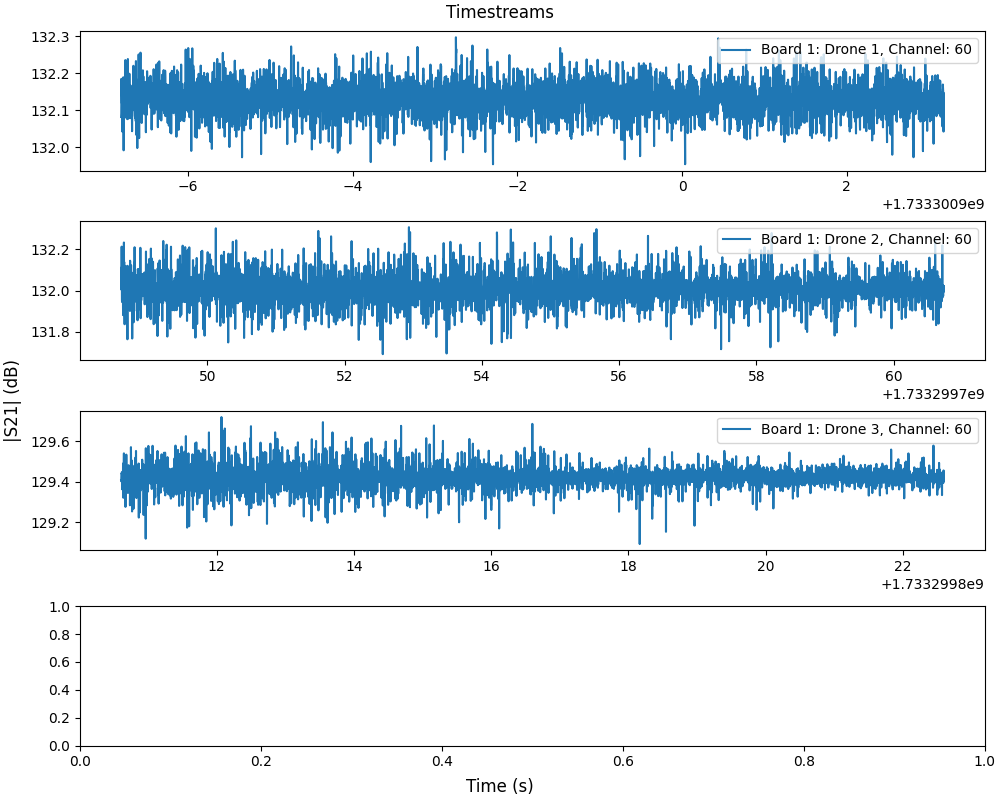

In [71]:
# Define timestamp of timestreams
timestamp = '1733299662_003'

# Plot timestreams
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all timestreams

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_tstream)
except:
    print("No figures currently open")

fig_tstream, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
channels = [[60],[60], [60]]
for drone, chans, ax in zip(drone_list, channels, np.ndarray.flatten(axes)):
    bid, drid = drone.split('.')
    fname = tstream_dir / (f'B{bid}D{drid}/' + tstream_name + timestamp + ".npy")
    plot_tstream(fname, chans = chans, figax = (fig_tstream, ax), label = f'Board {bid}: Drone {drid}')
fig_tstream.supxlabel("Time (s)")
fig_tstream.supylabel("|S21| (dB)")
fig_tstream.suptitle("Timestreams")

In [197]:
plt.clf()

58.138 0.0842199 0.0829398


{'Channel_1': {'T': 0.0, 'V': 0.0},
 'Channel_2': {'T': 58.003, 'V': 2755.4},
 'Channel_3': {'T': 48.925, 'V': 486.0},
 'Channel_4': {'T': 31.836, 'V': 9466.0},
 'Channel_5': {'T': 24.367, 'V': 5127.8},
 'Channel_6': {'T': 0.0, 'V': 0.1302},
 'Channel_7': {'T': 0.0, 'V': 0.0},
 'Channel_8': {'T': 0.0, 'V': 0.0}}